In [200]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# URL of the page to scrape
url = "https://www.espncricinfo.com/records/team/team-series-results/india-6/test-matches-1"  # Replace with target URL

# Send GET request to the webpage
response = requests.get(url)
if response.status_code == 200:
    soup = BeautifulSoup(response.text, 'html.parser')

    # Locate and extract data
    data = []
    for row in soup.find_all('tr'):  # Adjust based on the webpage structure
        columns = row.find_all('td')
        row_data = [col.text.strip() for col in columns]
        data.append(row_data)

    # Convert to DataFrame for analysis
    df = pd.DataFrame(data, columns=['Column1', 'Column2', 'Column3', 'column4'])  # Set appropriate column names
    print(df)
else:
    print(f"Failed to retrieve data. Status code: {response.status_code}")

                                        Column1  Column2      Column3  column4
0                             Series/Tournament   Season       Winner   Margin
1                   India in England Test Match     1932      England  1-0 (1)
2                  England in India Test Series  1933/34      England  2-0 (3)
3                  India in England Test Series     1936      England  2-0 (3)
4                  India in England Test Series     1946      England  1-0 (3)
..                                          ...      ...          ...      ...
175            India in West Indies Test Series     2023        India  1-0 (2)
176      Freedom Trophy (India in South Africa)  2023/24        drawn  1-1 (2)
177  Anthony de Mello Trophy (England in India)  2023/24        India  4-1 (5)
178             Bangladesh in India Test Series  2024/25        India  2-0 (2)
179            New Zealand in India Test Series  2024/25  New Zealand  3-0 (3)

[180 rows x 4 columns]


In [201]:
from google.colab import files
df.to_csv('data.csv', encoding = 'utf-8-sig')
files.download('data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [203]:
df= pd.read_csv('/content/data.csv')
df.head()

,Unnamed: 0,Column1,Column2,Column3,column4
0,0,Series/Tournament,Season,Winner,Margin
1,1,India in England Test Match,1932,England,1-0 (1)
2,2,England in India Test Series,1933/34,England,2-0 (3)
3,3,India in England Test Series,1936,England,2-0 (3)
4,4,India in England Test Series,1946,England,1-0 (3)


In [204]:
df.describe(include='all')

,Unnamed: 0,Column1,Column2,Column3,column4
count,180.000000,180,180,180,180
unique,NaN,36,105,11,37
top,NaN,England in India Test Series,2016/17,India,1-0 (3)
freq,NaN,14,4,77,19
mean,89.500000,NaN,NaN,NaN,NaN
std,52.105662,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN
25%,44.750000,NaN,NaN,NaN,NaN
50%,89.500000,NaN,NaN,NaN,NaN
75%,134.250000,NaN,NaN,NaN,NaN


In [205]:
df.dtypes

,0
Unnamed: 0,int64
Column1,object
Column2,object
Column3,object
column4,object


#Data Cleaning

In [206]:
df.drop('Unnamed: 0',axis=1,inplace=True)


In [207]:
df.reset_index(drop=True,inplace=True)
df

,Column1,Column2,Column3,column4
0,Series/Tournament,Season,Winner,Margin
1,India in England Test Match,1932,England,1-0 (1)
2,England in India Test Series,1933/34,England,2-0 (3)
3,India in England Test Series,1936,England,2-0 (3)
4,India in England Test Series,1946,England,1-0 (3)
...,...,...,...,...
175,India in West Indies Test Series,2023,India,1-0 (2)
176,Freedom Trophy (India in South Africa),2023/24,drawn,1-1 (2)
177,Anthony de Mello Trophy (England in India),2023/24,India,4-1 (5)
178,Bangladesh in India Test Series,2024/25,India,2-0 (2)


In [208]:
df.drop(0)
df=df.rename(columns={'Column1':'Series','Column2':'Season','Column3':'Winner','column4':'Margin'})
df

,Series,Season,Winner,Margin
0,Series/Tournament,Season,Winner,Margin
1,India in England Test Match,1932,England,1-0 (1)
2,England in India Test Series,1933/34,England,2-0 (3)
3,India in England Test Series,1936,England,2-0 (3)
4,India in England Test Series,1946,England,1-0 (3)
...,...,...,...,...
175,India in West Indies Test Series,2023,India,1-0 (2)
176,Freedom Trophy (India in South Africa),2023/24,drawn,1-1 (2)
177,Anthony de Mello Trophy (England in India),2023/24,India,4-1 (5)
178,Bangladesh in India Test Series,2024/25,India,2-0 (2)


In [209]:
df['Season']=df['Season'].astype(str)
df['Series']=df['Series'].astype(str)
df['Winner']=df['Winner'].astype(str)
df['Margin']=df['Margin'].astype(str)


In [210]:
df.dtypes

,0
Series,object
Season,object
Winner,object
Margin,object


In [211]:
df['Series'].unique()

array(['Series/Tournament', 'India in England Test Match',
       'England in India Test Series', 'India in England Test Series',
       'India in Australia Test Series',
       'West Indies in India Test Series',
       'Pakistan in India Test Series',
       'India in West Indies Test Series',
       'India in Pakistan Test Series',
       'New Zealand in India Test Series',
       'Australia in India Test Series',
       'India in New Zealand Test Series',
       'Golden Jubilee Test (England in India)',
       'Sri Lanka in India Test Match', 'India in Sri Lanka Test Series',
       'Sri Lanka in India Test Series', 'India in Zimbabwe Test Match',
       'India in South Africa Test Series',
       'Zimbabwe in India Test Match', 'India in New Zealand Test Match',
       'Border-Gavaskar Trophy (Australia in India)',
       'South Africa in India Test Series',
       'Asian Test Championship (India, Pakistan, Sri Lanka in Bangladesh/India/Pakistan/Sri Lanka)',
       'Border-Gavaska

Remove the trophy names so that we can have clear picture about the data

In [212]:
trophy_replacements= {
    "Golden Jubilee Test":" ",
    "Border-Gavaskar Trophy": " ",
    "Asian Test Championship":" ",
    "Pataudi Trophy":" ",
    "Freedom Trophy":" ",
    "Anthony de Mello Trophy":" ",
    "(" :" ",
    ")":" "
}

In [213]:
for trophy, replacement in trophy_replacements.items():
    df['Series'] = df['Series'].str.replace(trophy, replacement).str.strip()

In [214]:
df['Series'].unique()

array(['Series/Tournament', 'India in England Test Match',
       'England in India Test Series', 'India in England Test Series',
       'India in Australia Test Series',
       'West Indies in India Test Series',
       'Pakistan in India Test Series',
       'India in West Indies Test Series',
       'India in Pakistan Test Series',
       'New Zealand in India Test Series',
       'Australia in India Test Series',
       'India in New Zealand Test Series', 'England in India',
       'Sri Lanka in India Test Match', 'India in Sri Lanka Test Series',
       'Sri Lanka in India Test Series', 'India in Zimbabwe Test Match',
       'India in South Africa Test Series',
       'Zimbabwe in India Test Match', 'India in New Zealand Test Match',
       'Australia in India', 'South Africa in India Test Series',
       'India, Pakistan, Sri Lanka in Bangladesh/India/Pakistan/Sri Lanka',
       'India in Australia', 'India in Bangladesh Test Match',
       'Zimbabwe in India Test Series', 'India

In [215]:
df.drop(0)

,Series,Season,Winner,Margin
1,India in England Test Match,1932,England,1-0 (1)
2,England in India Test Series,1933/34,England,2-0 (3)
3,India in England Test Series,1936,England,2-0 (3)
4,India in England Test Series,1946,England,1-0 (3)
5,India in Australia Test Series,1947/48,Australia,4-0 (5)
...,...,...,...,...
175,India in West Indies Test Series,2023,India,1-0 (2)
176,India in South Africa,2023/24,drawn,1-1 (2)
177,England in India,2023/24,India,4-1 (5)
178,Bangladesh in India Test Series,2024/25,India,2-0 (2)


In [216]:
remove_test_name = {
    "Test Series":" ",
    "Test Match" :" "
}
for name,rpl in remove_test_name.items():
  df['Series'] = df['Series'].str.replace(name,rpl).str.strip()


In [217]:
df['Series'].unique()

array(['Series/Tournament', 'India in England', 'England in India',
       'India in Australia', 'West Indies in India', 'Pakistan in India',
       'India in West Indies', 'India in Pakistan',
       'New Zealand in India', 'Australia in India',
       'India in New Zealand', 'Sri Lanka in India', 'India in Sri Lanka',
       'India in Zimbabwe', 'India in South Africa', 'Zimbabwe in India',
       'South Africa in India',
       'India, Pakistan, Sri Lanka in Bangladesh/India/Pakistan/Sri Lanka',
       'India in Bangladesh', 'Bangladesh in India',
       'Afghanistan in India', 'India v New Zealand    in England'],
      dtype=object)

Dropping the series India, Pakistan, Sri Lanka in Bangladesh/India/Pakistan/Sri Lanka bcz it doesnt impact the data

In [218]:
np.where(df['Series']=='India, Pakistan, Sri Lanka in Bangladesh/India/Pakistan/Sri Lanka')

(array([90]),)

In [219]:
df.drop(90,axis=0,inplace=True)


In [220]:
df['Series'].unique()

array(['Series/Tournament', 'India in England', 'England in India',
       'India in Australia', 'West Indies in India', 'Pakistan in India',
       'India in West Indies', 'India in Pakistan',
       'New Zealand in India', 'Australia in India',
       'India in New Zealand', 'Sri Lanka in India', 'India in Sri Lanka',
       'India in Zimbabwe', 'India in South Africa', 'Zimbabwe in India',
       'South Africa in India', 'India in Bangladesh',
       'Bangladesh in India', 'Afghanistan in India',
       'India v New Zealand    in England'], dtype=object)

In [221]:
df.isnull().sum()

,0
Series,0
Season,0
Winner,0
Margin,0


In [222]:
df.head(20)

,Series,Season,Winner,Margin
0,Series/Tournament,Season,Winner,Margin
1,India in England,1932,England,1-0 (1)
2,England in India,1933/34,England,2-0 (3)
3,India in England,1936,England,2-0 (3)
4,India in England,1946,England,1-0 (3)
5,India in Australia,1947/48,Australia,4-0 (5)
6,West Indies in India,1948/49,West Indies,1-0 (5)
7,England in India,1951/52,drawn,1-1 (5)
8,India in England,1952,England,3-0 (4)
9,Pakistan in India,1952/53,India,2-1 (5)


In [223]:
df[['Touring Country','Host']]= df['Series'].str.extract(r'(\w+)\s+in\s+(\w+)')

In [224]:
df

,Series,Season,Winner,Margin,Touring Country,Host
0,Series/Tournament,Season,Winner,Margin,NaN,NaN
1,India in England,1932,England,1-0 (1),India,England
2,England in India,1933/34,England,2-0 (3),England,India
3,India in England,1936,England,2-0 (3),India,England
4,India in England,1946,England,1-0 (3),India,England
...,...,...,...,...,...,...
175,India in West Indies,2023,India,1-0 (2),India,West
176,India in South Africa,2023/24,drawn,1-1 (2),India,South
177,England in India,2023/24,India,4-1 (5),England,India
178,Bangladesh in India,2024/25,India,2-0 (2),Bangladesh,India


In [225]:
df['Touring Country'].unique()

array([nan, 'India', 'England', 'Indies', 'Pakistan', 'Zealand',
       'Australia', 'Lanka', 'Zimbabwe', 'Africa', 'Bangladesh',
       'Afghanistan'], dtype=object)

In [226]:
proper_name = {
    "Indies":"West Indies",
    "Zealand" :"New Zealand",
    "Lanka":"Sri Lanka",
    "Africa":"South Africa"
}
for name,rpl in proper_name.items():
  df['Touring Country'] = df['Touring Country'].str.replace(name,rpl).str.strip()

In [227]:
df['Host'].unique()

array([nan, 'England', 'India', 'Australia', 'West', 'Pakistan', 'New',
       'Sri', 'Zimbabwe', 'South', 'Bangladesh'], dtype=object)

In [228]:
proper_name = {
    "West":"West Indies",
    "New" :"New Zealand",
    "Sri":"Sri Lanka",
    "South":"South Africa"
}
for name,rpl in proper_name.items():
  df['Host'] = df['Host'].str.replace(name,rpl).str.strip()

In [229]:
df.columns

Index(['Series', 'Season', 'Winner', 'Margin', 'Touring Country', 'Host'], dtype='object')

In [230]:
df=df[['Touring Country', 'Host','Series', 'Season', 'Winner', 'Margin']]
df

,Touring Country,Host,Series,Season,Winner,Margin
0,NaN,NaN,Series/Tournament,Season,Winner,Margin
1,India,England,India in England,1932,England,1-0 (1)
2,England,India,England in India,1933/34,England,2-0 (3)
3,India,England,India in England,1936,England,2-0 (3)
4,India,England,India in England,1946,England,1-0 (3)
...,...,...,...,...,...,...
175,India,West Indies,India in West Indies,2023,India,1-0 (2)
176,India,South Africa,India in South Africa,2023/24,drawn,1-1 (2)
177,England,India,England in India,2023/24,India,4-1 (5)
178,Bangladesh,India,Bangladesh in India,2024/25,India,2-0 (2)


#India's Test performance in Home

In [231]:
df.to_csv('cleaned_data.csv', encoding = 'utf-8-sig')
files.download('cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [232]:
df1=pd.read_csv('/content/cleaned_data.csv')
df1.head()
df1.drop('Unnamed: 0',axis=1)
df1

,Unnamed: 0,Touring Country,Host,Series,Season,Winner,Margin
0,0,NaN,NaN,Series/Tournament,Season,Winner,Margin
1,1,India,England,India in England,1932,England,1-0 (1)
2,2,England,India,England in India,1933/34,England,2-0 (3)
3,3,India,England,India in England,1936,England,2-0 (3)
4,4,India,England,India in England,1946,England,1-0 (3)
...,...,...,...,...,...,...,...
174,175,India,West Indies,India in West Indies,2023,India,1-0 (2)
175,176,India,South Africa,India in South Africa,2023/24,drawn,1-1 (2)
176,177,England,India,England in India,2023/24,India,4-1 (5)
177,178,Bangladesh,India,Bangladesh in India,2024/25,India,2-0 (2)


In [233]:
df1.drop('Unnamed: 0',axis=1,inplace=True)


In [234]:
df1.drop(0)

,Touring Country,Host,Series,Season,Winner,Margin
1,India,England,India in England,1932,England,1-0 (1)
2,England,India,England in India,1933/34,England,2-0 (3)
3,India,England,India in England,1936,England,2-0 (3)
4,India,England,India in England,1946,England,1-0 (3)
5,India,Australia,India in Australia,1947/48,Australia,4-0 (5)
...,...,...,...,...,...,...
174,India,West Indies,India in West Indies,2023,India,1-0 (2)
175,India,South Africa,India in South Africa,2023/24,drawn,1-1 (2)
176,England,India,England in India,2023/24,India,4-1 (5)
177,Bangladesh,India,Bangladesh in India,2024/25,India,2-0 (2)


In [235]:
df1.dtypes

,0
Touring Country,object
Host,object
Series,object
Season,object
Winner,object
Margin,object


In [236]:
india_hosted_matches=df1[df1['Host']=='India']
india_hosted_matches['Host'].value_counts()

,count
Host,
India,88


India hosted 88 test series so far from 1934-2024

In [237]:
india_home_win=india_hosted_matches[india_hosted_matches['Winner']=='India']
india_home_win['Winner'].value_counts()

,count
Winner,
India,54


India has won 54 test series so far in Home

In [238]:
india_home_win['Host'].value_counts()/india_hosted_matches['Host'].value_counts()*100


,count
Host,
India,61.363636


India has 61 % win in home series

In [239]:
india_home_win1=india_hosted_matches['Winner'].value_counts().reset_index()
india_home_win1

,Winner,count
0,India,54
1,drawn,17
2,England,5
3,West Indies,5
4,Australia,4
5,Pakistan,1
6,South Africa,1
7,New Zealand,1


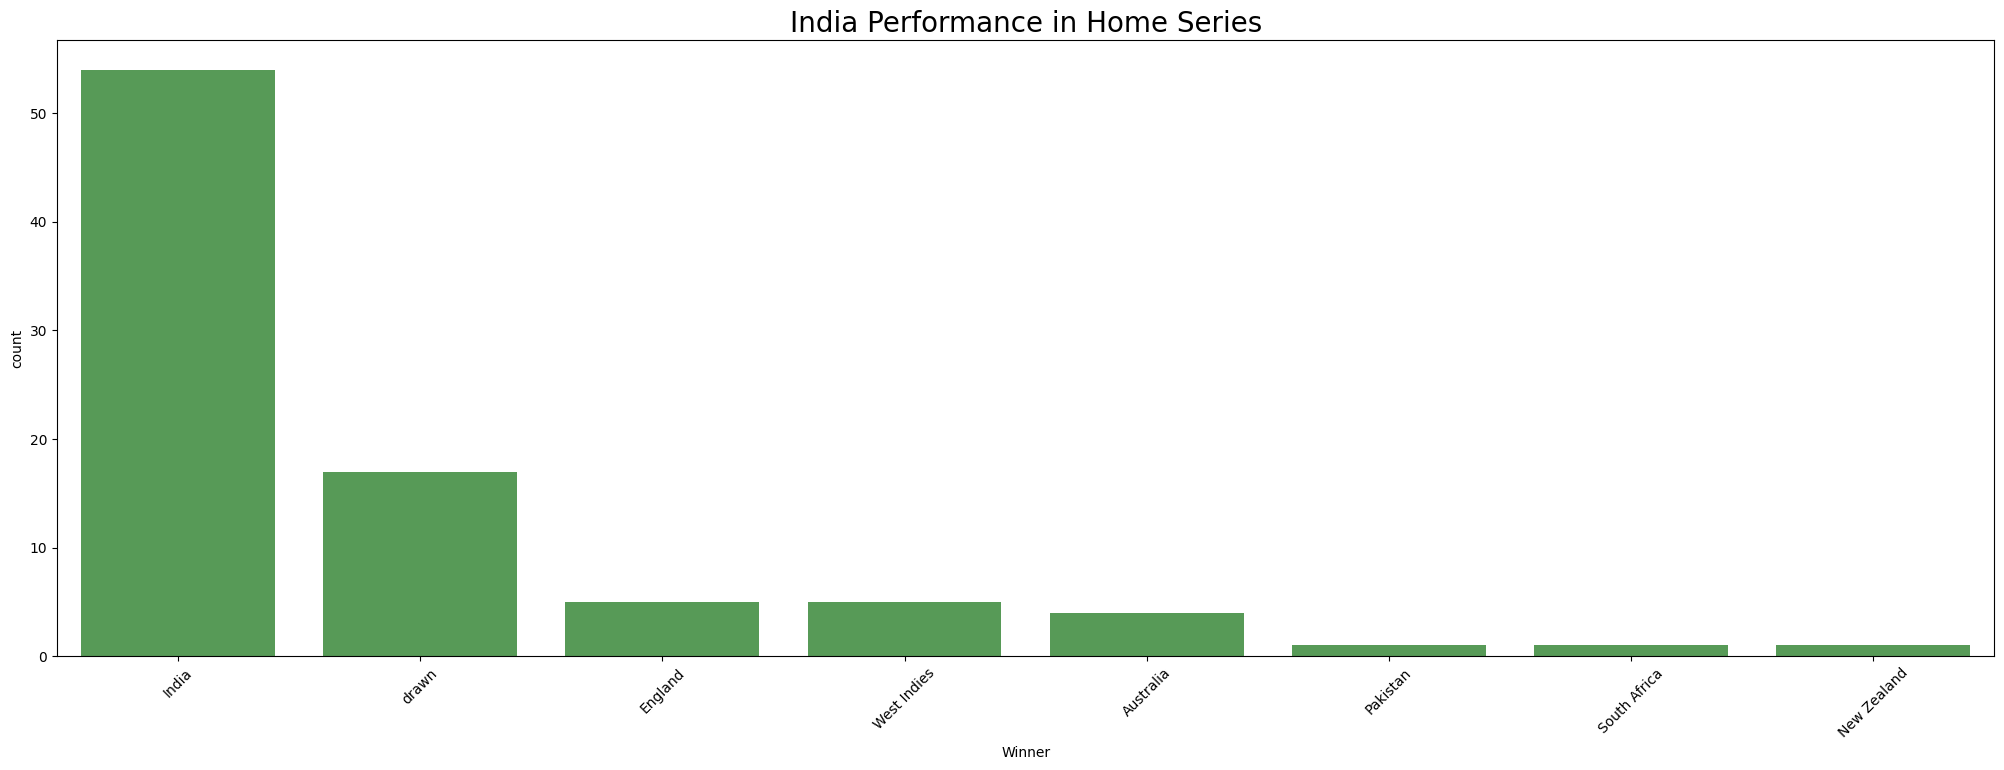

In [240]:
plt.figure(figsize=(25,8))
sns.barplot(x='Winner',y='count',data=india_home_win1,color='Green',alpha=0.7)
plt.xticks(rotation = 45,fontsize=10)
plt.title('India Performance in Home Series',fontsize=20)
plt.show()

In [241]:
india_home_win2=india_home_win['Touring Country'].value_counts().reset_index()
india_home_win2

,Touring Country,count
0,New Zealand,10
1,England,9
2,Australia,9
3,Sri Lanka,7
4,West Indies,5
5,South Africa,4
6,Pakistan,3
7,Zimbabwe,3
8,Bangladesh,3
9,Afghanistan,1


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'New Zealand'),
  Text(1, 0, 'England'),
  Text(2, 0, 'Australia'),
  Text(3, 0, 'Sri Lanka'),
  Text(4, 0, 'West Indies'),
  Text(5, 0, 'South Africa'),
  Text(6, 0, 'Pakistan'),
  Text(7, 0, 'Zimbabwe'),
  Text(8, 0, 'Bangladesh'),
  Text(9, 0, 'Afghanistan')])

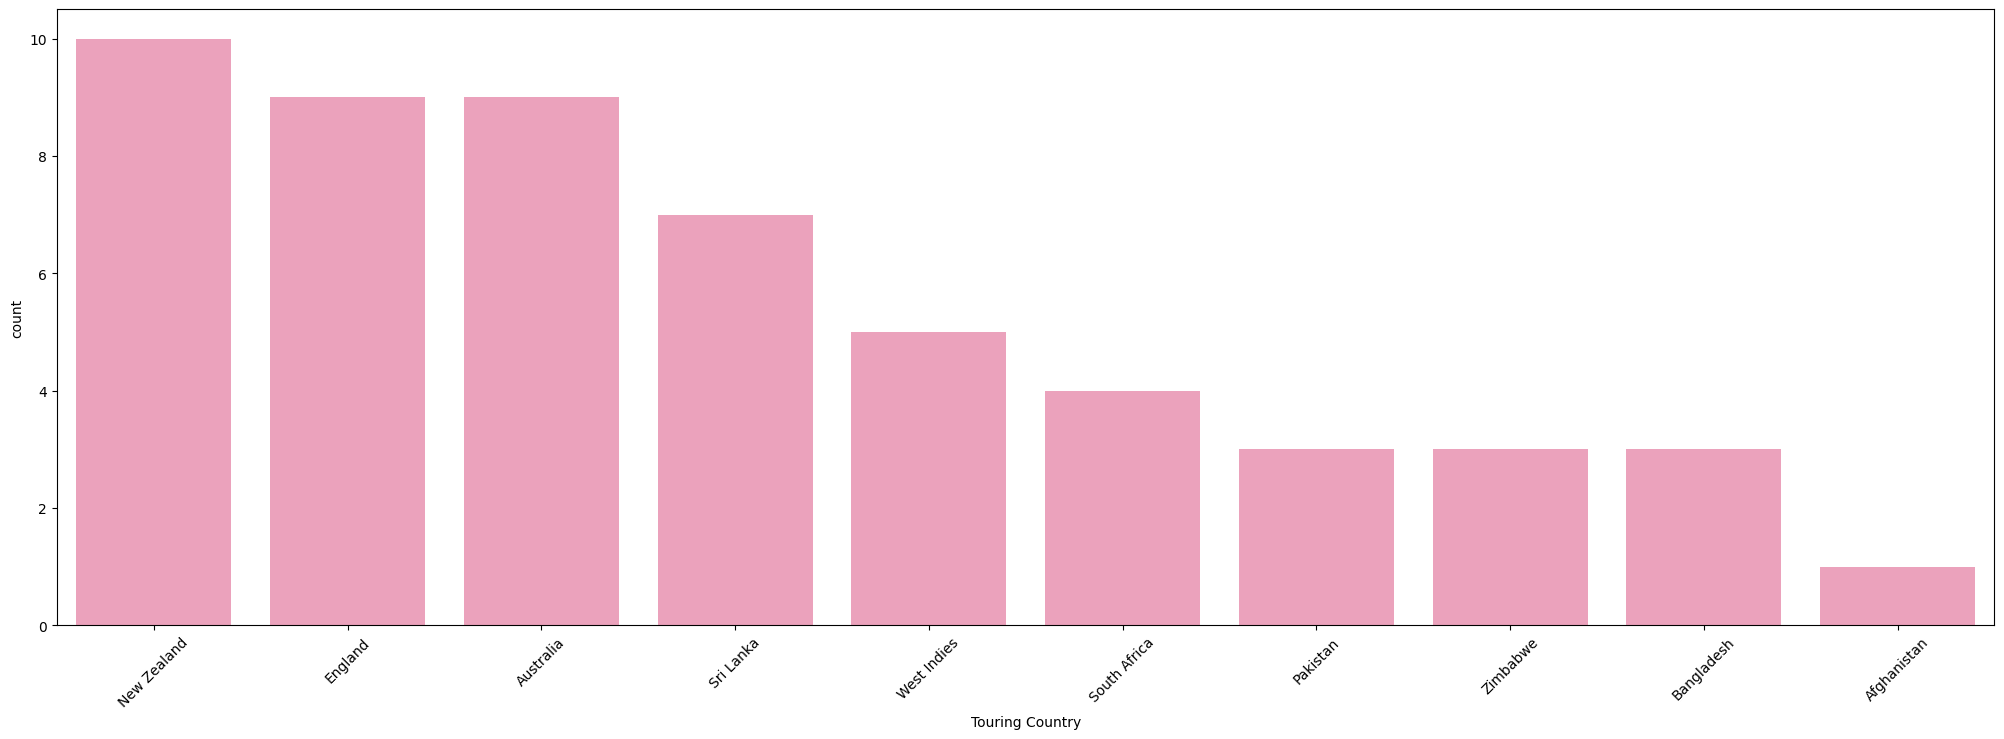

In [242]:
plt.figure(figsize=(25,8))
sns.barplot(x='Touring Country',y='count',data=india_home_win2,color='#f46a9b',alpha=0.7)
plt.xticks(rotation = 45,fontsize=10)

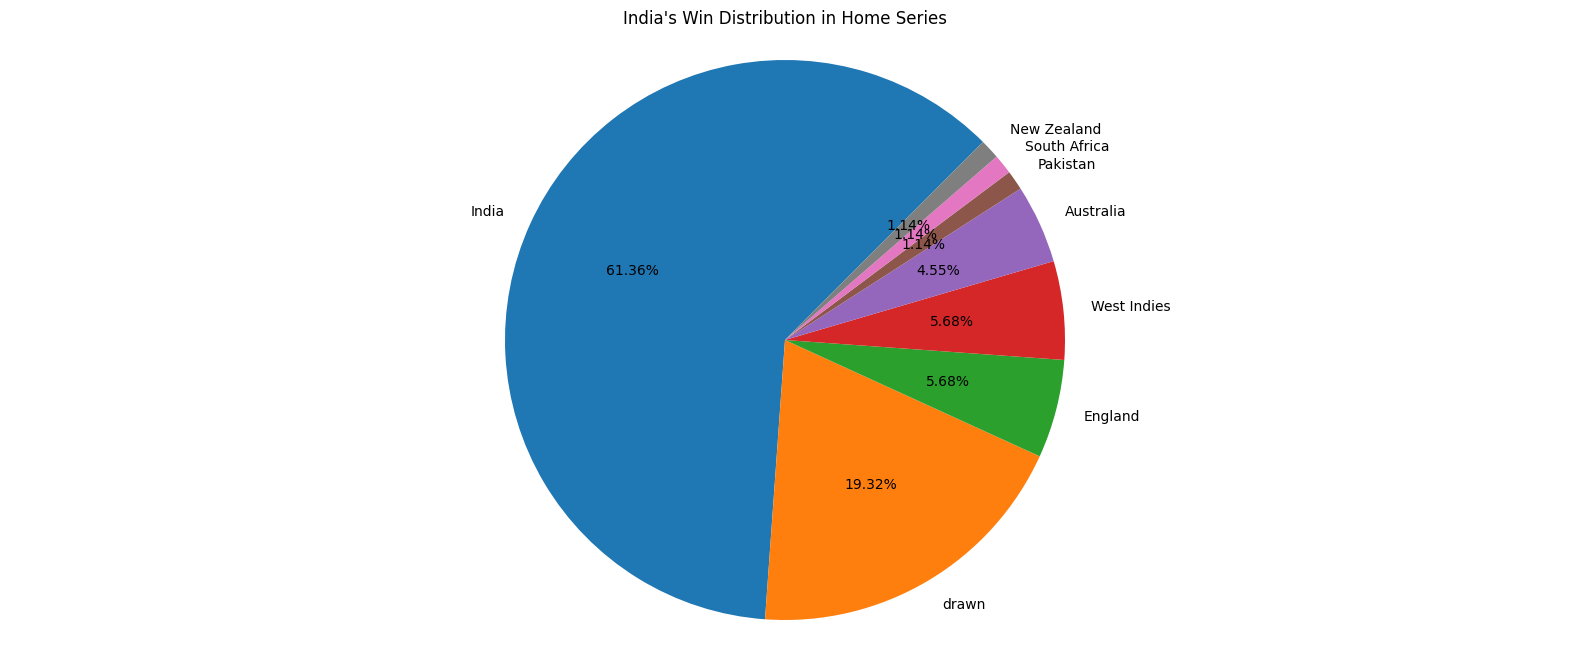

In [243]:
labels = india_home_win1['Winner']
sizes = india_home_win1['count']

plt.figure(figsize=(20, 8))  # Adjust figure size as needed
plt.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=45)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title("India's Win Distribution in Home Series")
plt.show()

India most home win in test came against Newzealand 10 series followed by England & Australia with 9 series

In [244]:
india_hosted_matches.head()

,Touring Country,Host,Series,Season,Winner,Margin
2,England,India,England in India,1933/34,England,2-0 (3)
6,West Indies,India,West Indies in India,1948/49,West Indies,1-0 (5)
7,England,India,England in India,1951/52,drawn,1-1 (5)
9,Pakistan,India,Pakistan in India,1952/53,India,2-1 (5)
12,New Zealand,India,New Zealand in India,1955/56,India,2-0 (5)


In [245]:
def matches(x):
  d=x.split('-')
  return d[0]
def matches1(x):
  d=x.split('-')
  return d[1]
india_hosted_matches['Win Matches']=india_hosted_matches['Margin'].apply(matches)
india_hosted_matches['Lose Matches']=india_hosted_matches['Margin'].apply(matches1)

<ipython-input-245-4ac66b0ce0f3>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india_hosted_matches['Win Matches']=india_hosted_matches['Margin'].apply(matches)
<ipython-input-245-4ac66b0ce0f3>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india_hosted_matches['Lose Matches']=india_hosted_matches['Margin'].apply(matches1)


In [246]:
def matches2(x):
  d=x.split('(')
  return d[0]

india_hosted_matches['Lose Matches']=india_hosted_matches['Lose Matches'].apply(matches2)

<ipython-input-246-bb8a2b67db0b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india_hosted_matches['Lose Matches']=india_hosted_matches['Lose Matches'].apply(matches2)


In [247]:
india_hosted_matches

,Touring Country,Host,Series,Season,Winner,Margin,Win Matches,Lose Matches
2,England,India,England in India,1933/34,England,2-0 (3),2,0
6,West Indies,India,West Indies in India,1948/49,West Indies,1-0 (5),1,0
7,England,India,England in India,1951/52,drawn,1-1 (5),1,1
9,Pakistan,India,Pakistan in India,1952/53,India,2-1 (5),2,1
12,New Zealand,India,New Zealand in India,1955/56,India,2-0 (5),2,0
...,...,...,...,...,...,...,...,...
170,Sri Lanka,India,Sri Lanka in India,2021/22,India,2-0 (2),2,0
173,Australia,India,Australia in India,2022/23,India,2-1 (4),2,1
176,England,India,England in India,2023/24,India,4-1 (5),4,1
177,Bangladesh,India,Bangladesh in India,2024/25,India,2-0 (2),2,0


In [248]:
india_hosted_matches['Win Matches'] = pd.to_numeric(india_hosted_matches['Win Matches'].str.strip().replace('', '0'), errors='coerce').astype(int)


<ipython-input-248-c4dde8ddb229>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india_hosted_matches['Win Matches'] = pd.to_numeric(india_hosted_matches['Win Matches'].str.strip().replace('', '0'), errors='coerce').astype(int)


In [249]:
india_hosted_matches['Win Matches'].sum()

148

In [250]:
india_hosted_matches['Lose Matches'] = pd.to_numeric(india_hosted_matches['Lose Matches'].str.strip().replace('', '0'), errors='coerce').astype(int)

<ipython-input-250-79ab25c56128>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india_hosted_matches['Lose Matches'] = pd.to_numeric(india_hosted_matches['Lose Matches'].str.strip().replace('', '0'), errors='coerce').astype(int)


In [251]:
lose=india_hosted_matches['Lose Matches'].sum()

India has a whopping record of winning 148 test matches and losing only 28 test matches in India

In [253]:
def season(x):
  d=x.split('/')
  return d[0]

india_hosted_matches['Season']=india_hosted_matches['Season'].apply(season)

<ipython-input-253-9d182755ed35>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india_hosted_matches['Season']=india_hosted_matches['Season'].apply(season)


In [255]:
india_hosted_matches['Season'] = pd.to_numeric(india_hosted_matches['Season'], errors='coerce')


<ipython-input-255-e1f01ade09be>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  india_hosted_matches['Season'] = pd.to_numeric(india_hosted_matches['Season'], errors='coerce')


In [256]:
india_hosted_matches

,Touring Country,Host,Series,Season,Winner,Margin,Win Matches,Lose Matches
2,England,India,England in India,1933,England,2-0 (3),2,0
6,West Indies,India,West Indies in India,1948,West Indies,1-0 (5),1,0
7,England,India,England in India,1951,drawn,1-1 (5),1,1
9,Pakistan,India,Pakistan in India,1952,India,2-1 (5),2,1
12,New Zealand,India,New Zealand in India,1955,India,2-0 (5),2,0
...,...,...,...,...,...,...,...,...
170,Sri Lanka,India,Sri Lanka in India,2021,India,2-0 (2),2,0
173,Australia,India,Australia in India,2022,India,2-1 (4),2,1
176,England,India,England in India,2023,India,4-1 (5),4,1
177,Bangladesh,India,Bangladesh in India,2024,India,2-0 (2),2,0


In [264]:
india_winning_streak=india_hosted_matches[india_hosted_matches['Season']>2012]

In [265]:
india_winning_streak['Win Matches'].sum()

41

In [266]:
india_winning_streak['Lose Matches'].sum()

4

We have taken test matches after 2012 since India had a winning streak from 2012 -2024 . Within this period India have won 41 test and loss only 4 tests.

In [273]:
india_winning_streak1=india_hosted_matches[(india_hosted_matches['Season']>2012) & (india_hosted_matches['Winner']=='India')]
india_winning_streak1['Touring Country'].value_counts().reset_index()

,Touring Country,count
0,England,3
1,Bangladesh,3
2,West Indies,2
3,South Africa,2
4,New Zealand,2
5,Australia,2
6,Sri Lanka,2
7,Afghanistan,1


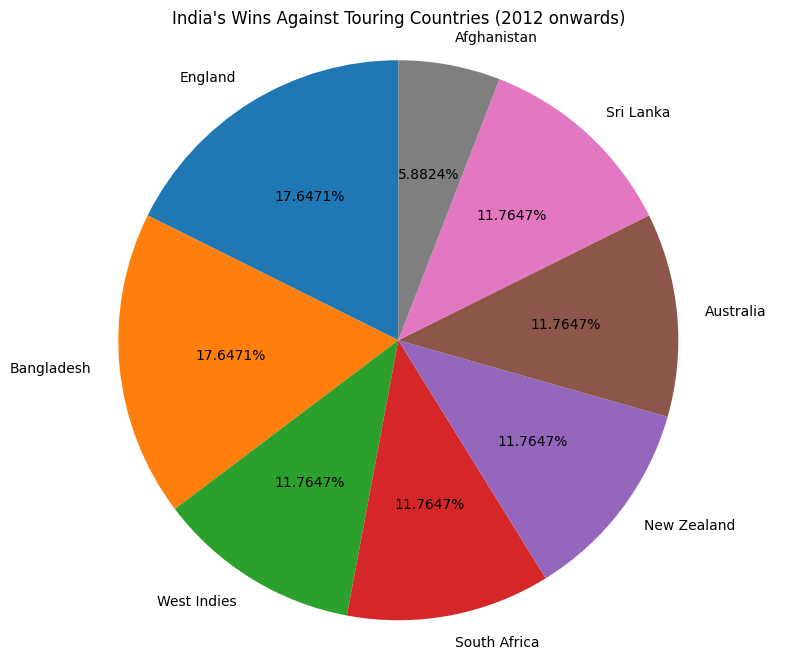

In [278]:
country_counts = india_winning_streak1['Touring Country'].value_counts().reset_index()

plt.figure(figsize=(10, 8))
plt.pie(country_counts['count'], labels=country_counts['Touring Country'], autopct='%1.4f%%', startangle=90)
plt.axis('equal')
plt.title("India's Wins Against Touring Countries (2012 onwards)")
plt.show()